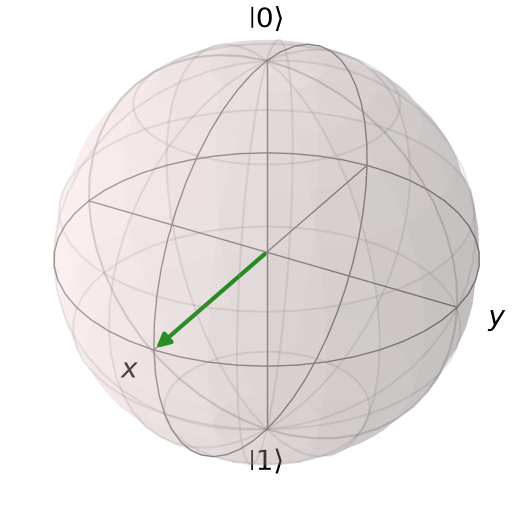

In [4]:
import qutip as qt
import matplotlib.pyplot as plt

# Create the Bloch sphere object
b = qt.Bloch()

# Add a state (e.g., the |+> state)
psi = (qt.basis(2, 0) + qt.basis(2, 1)).unit()
b.add_states(psi)

# Show the sphere
b.show()

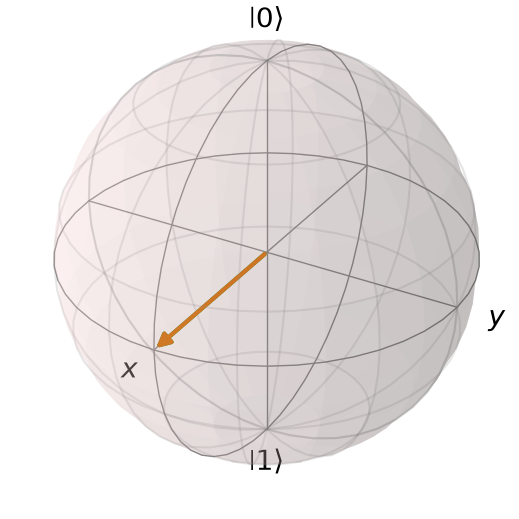

In [6]:
import numpy as np
from qutip.qip.operations import rx

# Create the rotation gate (angle theta = pi/2)
rot_gate = rx(np.pi / 2)

# Apply the gate to your state (using the 'psi' you defined earlier)
psi_rotated = rot_gate * psi

# Now add it to the Bloch sphere
b.add_states(psi_rotated)
b.show()

In [7]:
import qutip as qt

# Define a Pauli-X gate
op = qt.sigmax()

# Print its internal structure
print(f"Type: {type(op)}")
print(f"Data:\n{op.full()}")
print(f"Dimensions: {op.dims}")

Type: <class 'qutip.core.qobj.Qobj'>
Data:
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
Dimensions: [[2], [2]]


In [8]:
import qutip as qt
import numpy as np

# 1. Parameters
N = 10  # Number of cavity fock states
w_c = 1.0  # Cavity frequency
w_a = 1.0  # Atom frequency
g = 0.05   # Coupling strength

# 2. Operators
a = qt.tensor(qt.destroy(N), qt.qeye(2))
sm = qt.tensor(qt.qeye(N), qt.destroy(2))  # sigma_minus

# 3. Hamiltonian
H = w_c * a.dag() * a + w_a * sm.dag() * sm + g * (a.dag() * sm + a * sm.dag())

# 4. Find the ground state
evals, evecs = H.eigenstates()
ground_state = evecs[0]

print("Ground state energy:", evals[0])

Ground state energy: 0.0


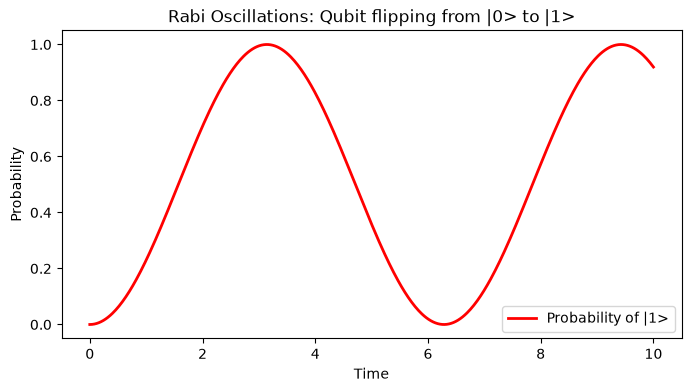

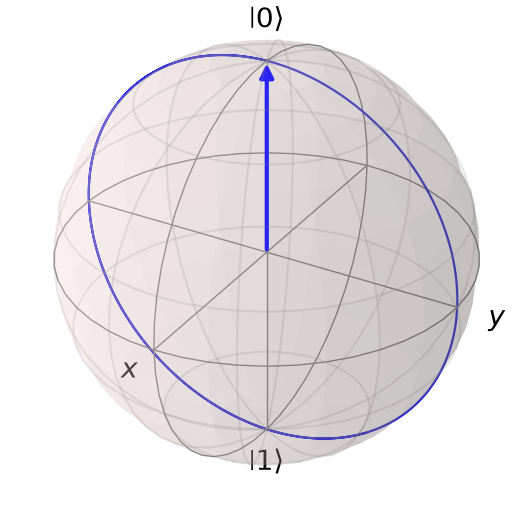

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# ---------------------------------------------------------
# 1. DEFINE THE PHYSICS
# ---------------------------------------------------------
omega_x = 1.0  # Drive strength
H = (omega_x / 2.0) * qt.sigmax()  # Hamiltonian
psi0 = qt.basis(2, 0)  # Initial ground state |0>

# ---------------------------------------------------------
# 2. TIME EVOLUTION
# ---------------------------------------------------------
tlist = np.linspace(0, 10, 500)

# Solves the system tracking X, Y, and Z expectations
result = qt.sesolve(H, psi0, tlist, e_ops=[qt.sigmax(), qt.sigmay(), qt.sigmaz()])

# Extract coordinates
exp_x = result.expect[0]
exp_y = result.expect[1]
exp_z = result.expect[2]

# ---------------------------------------------------------
# 3. VISUALIZATION 1: 2D Graph
# ---------------------------------------------------------
plt.figure(figsize=(8, 4))
p_excited = (1 - exp_z) / 2  # Convert Z-coordinate to excited state probability

plt.plot(tlist, p_excited, 'r', lw=2, label="Probability of |1>")
plt.xlabel('Time')
plt.ylabel('Probability')
plt.title('Rabi Oscillations: Qubit flipping from |0> to |1>')
plt.legend()
plt.show()

# ---------------------------------------------------------
# 4. VISUALIZATION 2: Bloch Sphere Trajectory
# ---------------------------------------------------------
b = qt.Bloch()
b.add_points([exp_x, exp_y, exp_z], meth='l')  # Draw trajectory line
b.add_states(psi0, colors='b')  # FIXED: Explicitly named the color argument
b.show()

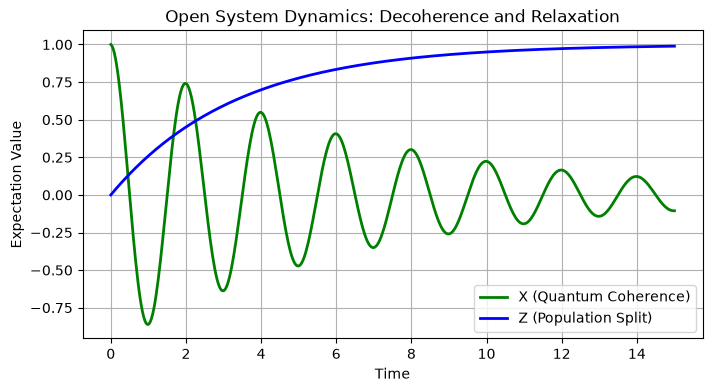

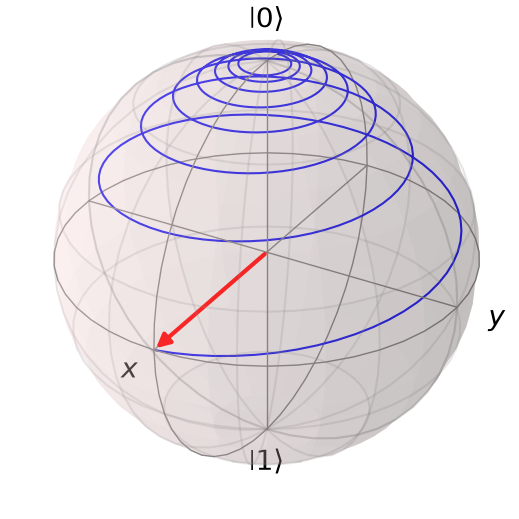

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# ---------------------------------------------------------
# 1. DEFINE THE PHYSICS & NOISE
# ---------------------------------------------------------
# A qubit splitting frequency
omega = 2.0 * np.pi * 0.5 
H = (omega / 2.0) * qt.sigmaz()

# Start the qubit on the equator (a perfect 50/50 superposition)
psi0 = (qt.basis(2, 0) + qt.basis(2, 1)).unit()

# Define the environmental noise (Collapse Operators)
gamma = 0.3  # Decay rate
# qt.destroy(2) acts as the lowering operator, pulling the qubit from |1> to |0>
c_ops = [np.sqrt(gamma) * qt.destroy(2)]

# ---------------------------------------------------------
# 2. OPEN SYSTEM TIME EVOLUTION
# ---------------------------------------------------------
tlist = np.linspace(0, 15, 500)

# We use mesolve instead of sesolve to include the c_ops (collapse operators)
result = qt.mesolve(H, psi0, tlist, c_ops=c_ops, e_ops=[qt.sigmax(), qt.sigmay(), qt.sigmaz()])

exp_x = result.expect[0]
exp_y = result.expect[1]
exp_z = result.expect[2]

# ---------------------------------------------------------
# 3. VISUALIZATION 1: 2D Decay Graph
# ---------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(tlist, exp_x, 'g', lw=2, label="X (Quantum Coherence)")
plt.plot(tlist, exp_z, 'b', lw=2, label="Z (Population Split)")
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.title('Open System Dynamics: Decoherence and Relaxation')
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 4. VISUALIZATION 2: The Spiral Trajectory
# ---------------------------------------------------------
b = qt.Bloch()
b.add_points([exp_x, exp_y, exp_z], meth='l') # Continuous line for the spiral
b.add_states(psi0, colors='r')                # Initial state vector in red
b.show()

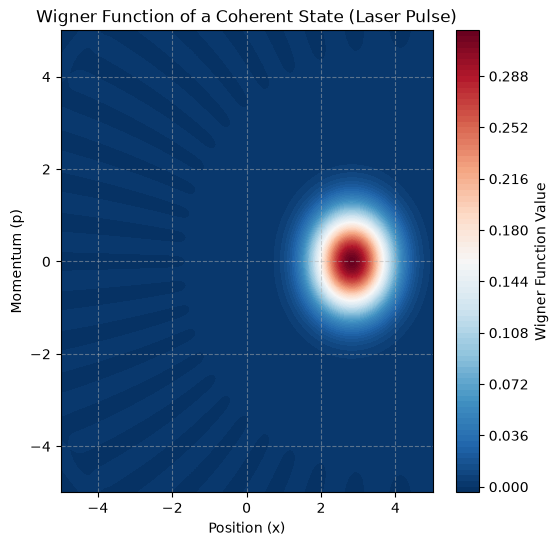

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# ---------------------------------------------------------
# 1. DEFINE THE CAVITY AND STATE
# ---------------------------------------------------------
N = 30          # Maximum number of photons to track (matrix size)
alpha = 2.0     # The amplitude of our laser state (complex number)

# Create a coherent state |alpha> in a cavity of size N
psi = qt.coherent(N, alpha)

# ---------------------------------------------------------
# 2. CALCULATE THE WIGNER FUNCTION
# ---------------------------------------------------------
# Define a grid for position (x) and momentum (p)
xvec = np.linspace(-5, 5, 200)
pvec = np.linspace(-5, 5, 200)

# QuTiP calculates the quasi-probability distribution across the grid
W = qt.wigner(psi, xvec, pvec)

# ---------------------------------------------------------
# 3. VISUALIZATION
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the 2D contour layout
contour = ax.contourf(xvec, pvec, W, 100, cmap='RdBu_r')

# Add a colorbar to show the scale
fig.colorbar(contour, ax=ax, label='Wigner Function Value')

ax.set_xlabel('Position (x)')
ax.set_ylabel('Momentum (p)')
ax.set_title('Wigner Function of a Coherent State (Laser Pulse)')
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

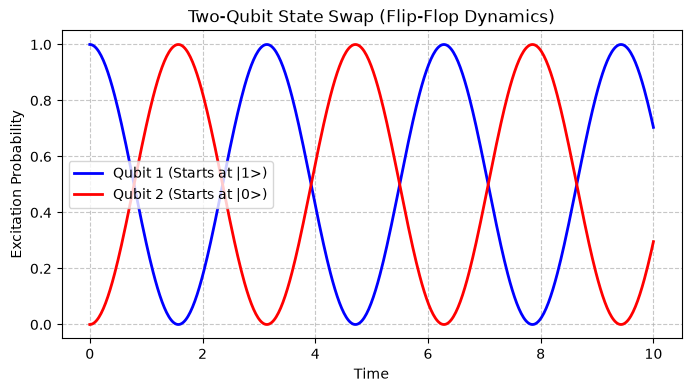

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# ---------------------------------------------------------
# 1. DEFINE THE TWO-QUBIT SYSTEM
# ---------------------------------------------------------
# Interaction strength between the two qubits
J = 1.0  

# Hamiltonian: H = 0.5 * J * (X1*X2 + Y1*Y2)
# This represents an exchange interaction (flip-flop coupling)
H = 0.5 * J * (qt.tensor(qt.sigmax(), qt.sigmax()) + qt.tensor(qt.sigmay(), qt.sigmay()))

# Initial state: Qubit 1 is excited (|1>), Qubit 2 is in ground (|0>)
# Combined state vector is |10>
psi0 = qt.tensor(qt.basis(2, 1), qt.basis(2, 0))

# ---------------------------------------------------------
# 2. DEFINE MEASUREMENT OPERATORS (TRACKERS)
# ---------------------------------------------------------
# We want to measure the number of excitations (0 or 1) on each individual qubit.
# qt.num(2) is the number operator for a 2-level system.
n1 = qt.tensor(qt.num(2), qt.qeye(2))  # Tracks Qubit 1, ignores Qubit 2
n2 = qt.tensor(qt.qeye(2), qt.num(2))  # Ignores Qubit 1, tracks Qubit 2

# ---------------------------------------------------------
# 3. TIME EVOLUTION
# ---------------------------------------------------------
tlist = np.linspace(0, 10, 500)

# Evolve using the closed-system solver with our custom trackers
result = qt.sesolve(H, psi0, tlist, e_ops=[n1, n2])

# ---------------------------------------------------------
# 4. VISUALIZATION
# ---------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(tlist, result.expect[0], 'b', lw=2, label="Qubit 1 (Starts at |1>)")
plt.plot(tlist, result.expect[1], 'r', lw=2, label="Qubit 2 (Starts at |0>)")

plt.xlabel('Time')
plt.ylabel('Excitation Probability')
plt.title('Two-Qubit State Swap (Flip-Flop Dynamics)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [17]:
import numpy as np
import qutip as qt
from qutip_qip.circuit import QubitCircuit

# ---------------------------------------------------------
# 1. CONSTRUCT THE QUANTUM CIRCUIT
# ---------------------------------------------------------
qc = QubitCircuit(2)

# Step 1: Put Qubit 0 into a superposition using a Hadamard ("H") gate
qc.add_gate("H", targets=0)

# Step 2: Entangle Qubit 1 with Qubit 0 using a Controlled-NOT ("CNOT") gate
qc.add_gate("CNOT", targets=1, controls=0)

# ---------------------------------------------------------
# 2. EXECUTE THE SIMULATION WITH INITIAL STATE
# ---------------------------------------------------------
# FIXED: Explicitly define the starting state |00>
psi0 = qt.tensor(qt.basis(2, 0), qt.basis(2, 0))

# Run the circuit starting from psi0
final_state = qc.run(state=psi0)

# ---------------------------------------------------------
# 3. DISPLAY AND ANALYZE THE EXTREME ENTANGLEMENT
# ---------------------------------------------------------
print("--- Final Quantum State Vector ---")
print(final_state)

# Inspect the exact probabilities by looking at the density matrix
density_matrix = final_state * final_state.dag()
print("\n--- Density Matrix (Probabilities on the diagonal) ---")
print(density_matrix.full())

--- Final Quantum State Vector ---
Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.        ]
 [0.        ]
 [0.70710678]]

--- Density Matrix (Probabilities on the diagonal) ---
[[0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]]


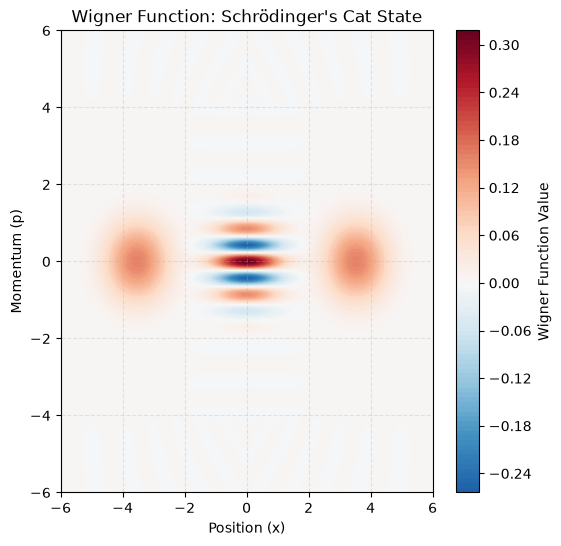

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# ---------------------------------------------------------
# 1. CREATE THE SCHRODINGER'S CAT STATE
# ---------------------------------------------------------
N = 35          # Maximum photon capacity of the cavity
alpha = 2.5     # Size/amplitude of the cat's states

# Create a coherent state pointing "Right" and one pointing "Left"
psi_right = qt.coherent(N, alpha)
psi_left = qt.coherent(N, -alpha)

# Superimpose them: The cat is alive (+alpha) AND dead (-alpha) simultaneously
psi_cat = (psi_right + psi_left).unit()

# ---------------------------------------------------------
# 2. COMPUTE THE PHASE-SPACE MAP (WIGNER FUNCTION)
# ---------------------------------------------------------
xvec = np.linspace(-6, 6, 250)
pvec = np.linspace(-6, 6, 250)
W = qt.wigner(psi_cat, xvec, pvec)

# ---------------------------------------------------------
# 3. VISUALIZATION
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))

# Plot using a Red-Blue color map ('RdBu_r') so negative values stand out clearly
contour = ax.contourf(xvec, pvec, W, 100, cmap='RdBu_r', vmin=-1/np.pi, vmax=1/np.pi)
fig.colorbar(contour, ax=ax, label='Wigner Function Value')

ax.set_xlabel('Position (x)')
ax.set_ylabel('Momentum (p)')
ax.set_title("Wigner Function: Schrödinger's Cat State")
ax.grid(True, linestyle='--', alpha=0.3)

plt.show()

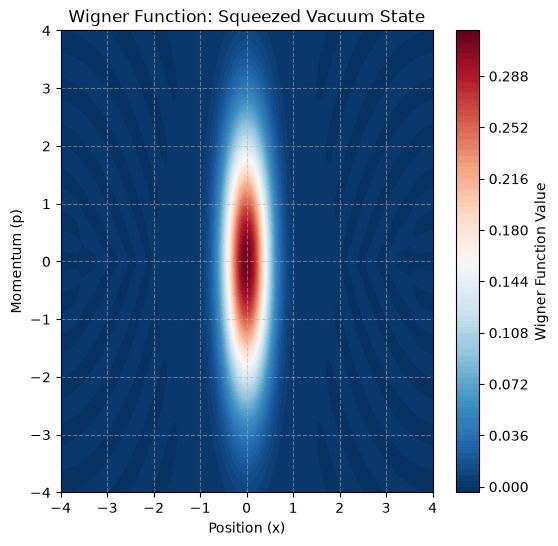

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# ---------------------------------------------------------
# 1. CREATE A SQUEEZED VACUUM STATE
# ---------------------------------------------------------
N = 40        # Maximum photon capacity of the cavity
r = 0.75      # Squeezing strength (higher = narrower ellipse)
theta = 0.0   # Squeezing angle (determines rotation)

# Start with the pure vacuum state |0> (zero photons)
vac = qt.basis(N, 0)

# Create the squeezing operator S(z) where z = r * e^(i * theta)
z = r * np.exp(1j * theta)
S = qt.squeeze(N, z)

# Apply the operator to the vacuum to "squeeze" the uncertainty
psi_squeezed = S * vac

# ---------------------------------------------------------
# 2. COMPUTE THE PHASE-SPACE MAP (WIGNER FUNCTION)
# ---------------------------------------------------------
xvec = np.linspace(-4, 4, 200)
pvec = np.linspace(-4, 4, 200)
W = qt.wigner(psi_squeezed, xvec, pvec)

# ---------------------------------------------------------
# 3. VISUALIZATION
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the 2D contour layout
contour = ax.contourf(xvec, pvec, W, 100, cmap='RdBu_r')
fig.colorbar(contour, ax=ax, label='Wigner Function Value')

ax.set_xlabel('Position (x)')
ax.set_ylabel('Momentum (p)')
ax.set_title('Wigner Function: Squeezed Vacuum State')
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

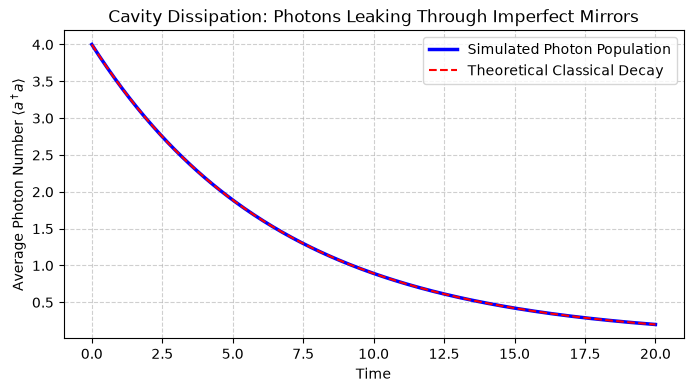

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# ---------------------------------------------------------
# 1. DEFINE THE CAVITY & THE LEAKAGE
# ---------------------------------------------------------
N = 25          # Photon capacity limit of the cavity
omega = 1.0     # Natural oscillation frequency of the cavity
a = qt.destroy(N)  # Annihilation operator for the cavity

# Hamiltonian for a standard harmonic oscillator
H = omega * a.dag() * a

# Start with a coherent state of alpha = 2.0
# The average number of photons initially is |alpha|^2 = 4.0
psi0 = qt.coherent(N, 2.0)

# Define the leakage: kappa is the cavity dissipation rate
kappa = 0.15
c_ops = [np.sqrt(kappa) * a]  # Lowering operator 'a' removes photons from the cavity

# ---------------------------------------------------------
# 2. TIME EVOLUTION
# ---------------------------------------------------------
tlist = np.linspace(0, 20, 300)

# Track the photon number operator (a^dag * a) over time
photon_number_op = a.dag() * a
result = qt.mesolve(H, psi0, tlist, c_ops=c_ops, e_ops=[photon_number_op])

# ---------------------------------------------------------
# 3. VISUALIZATION
# ---------------------------------------------------------
plt.figure(figsize=(8, 4))

# Plot QuTiP's simulated data
plt.plot(tlist, result.expect[0], 'b-', lw=2.5, label='Simulated Photon Population')

# Plot the exact theoretical exponential decay rule for comparison
plt.plot(tlist, 4.0 * np.exp(-kappa * tlist), 'r--', lw=1.5, label='Theoretical Classical Decay')

plt.xlabel('Time')
# FIXED: Added the 'r' prefix to make it a raw string for LaTeX formatting
plt.ylabel(r'Average Photon Number $\langle a^\dagger a \rangle$')
plt.title('Cavity Dissipation: Photons Leaking Through Imperfect Mirrors')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

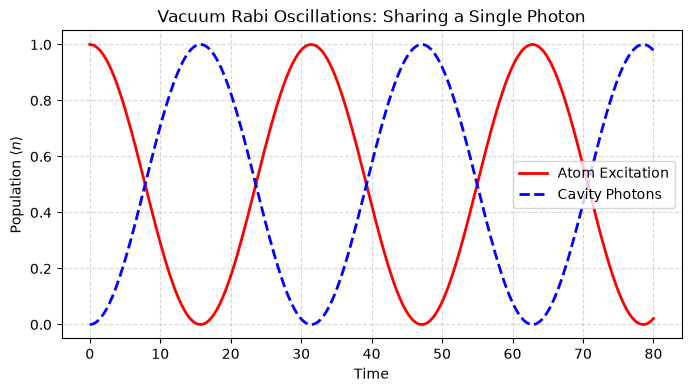

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# ---------------------------------------------------------
# 1. SETUP THE JAYNES-CUMMINGS SYSTEM
# ---------------------------------------------------------
N = 10          # Maximum photon capacity limit of the cavity
omega = 1.0     # Frequency of both the cavity and the atom (Resonance)
g = 0.1         # Light-matter coupling strength (how fast they talk)

# Define operators in the joint tensor Hilbert space
# System layout: [Cavity, Qubit]
a = qt.tensor(qt.destroy(N), qt.qeye(2))       # Cavity photon destroyer
sm = qt.tensor(qt.qeye(N), qt.destroy(2))     # Qubit excitation destroyer

# Hamiltonian: Cavity Energy + Atom Energy + Interaction Energy
H = omega * a.dag() * a + omega * sm.dag() * sm + g * (a.dag() * sm + a * sm.dag())

# Initial state: Cavity has 0 photons, Atom is excited (|1>)
# State representation: |0>⊗|1>
psi0 = qt.tensor(qt.basis(N, 0), qt.basis(2, 1))

# ---------------------------------------------------------
# 2. TIME EVOLUTION
# ---------------------------------------------------------
tlist = np.linspace(0, 80, 500)

# Trackers for number of photons and atom excitation state
n_cav = a.dag() * a
n_qubit = sm.dag() * sm

# Solve using the closed system solver
result = qt.sesolve(H, psi0, tlist, e_ops=[n_cav, n_qubit])

# ---------------------------------------------------------
# 3. VISUALIZATION
# ---------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(tlist, result.expect[1], 'r-', lw=2, label='Atom Excitation')
plt.plot(tlist, result.expect[0], 'b--', lw=2, label='Cavity Photons')

plt.xlabel('Time')
plt.ylabel(r'Population $\langle n \rangle$')
plt.title('Vacuum Rabi Oscillations: Sharing a Single Photon')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

/Users/user/Documents/QuTiP/venv/lib/python3.12/site-packages/qutip/solver/sesolve.py:117: FutureWarning: The signature f(t, args) is deprecated and will be removed in QuTiP 5.5. Please update your function to the pythonic signature f(t, **kwargs) to maintain compatibility.
  H = QobjEvo(H, args=args, tlist=tlist)


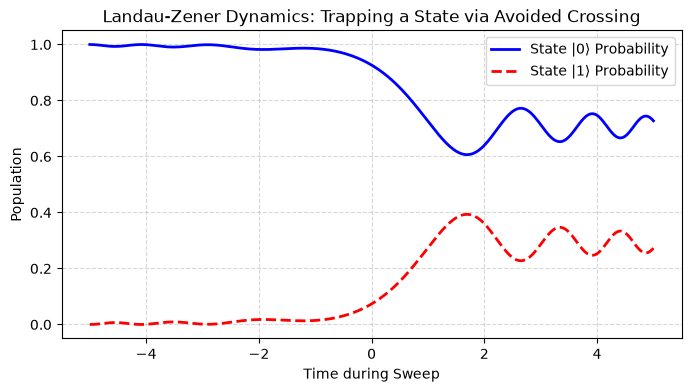

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# ---------------------------------------------------------
# 1. DEFINE A TIME-DEPENDENT HAMILTONIAN FUNCTION
# ---------------------------------------------------------
# QuTiP calls this function at every time step to get the current Hamiltonian matrix
def hamiltonian_t(t, args):
    v = args['v']            # The speed of our parameter sweep
    delta = args['delta']    # The minimum energy gap size (tunneling coupling)
    
    # Energy levels change linearly with time (v * t), while delta stays constant
    H_t = (v * t / 2.0) * qt.sigmaz() + (delta / 2.0) * qt.sigmax()
    return H_t

# ---------------------------------------------------------
# 2. SETUP THE SIMULATION PARAMETERS
# ---------------------------------------------------------
# Create an argument dictionary to pass to our function
args = {'v': 1.5, 'delta': 0.6}

# We sweep time from negative (-5) to positive (+5)
tlist = np.linspace(-5, 5, 300)

# Start 100% in the ground state |0>
psi0 = qt.basis(2, 0)

# ---------------------------------------------------------
# 3. RUN THE SIMULATION
# ---------------------------------------------------------
# We track the individual populations of state |0> and state |1> directly
p0_op = qt.basis(2, 0) * qt.basis(2, 0).dag()
p1_op = qt.basis(2, 1) * qt.basis(2, 1).dag()

# Pass the function name and the 'args' dictionary into the solver
result = qt.sesolve(hamiltonian_t, psi0, tlist, e_ops=[p0_op, p1_op], args=args)

# ---------------------------------------------------------
# 4. VISUALIZATION
# ---------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(tlist, result.expect[0], 'b-', lw=2, label=r'State $|0\rangle$ Probability')
plt.plot(tlist, result.expect[1], 'r--', lw=2, label=r'State $|1\rangle$ Probability')

plt.xlabel('Time during Sweep')
plt.ylabel('Population')
plt.title('Landau-Zener Dynamics: Trapping a State via Avoided Crossing')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

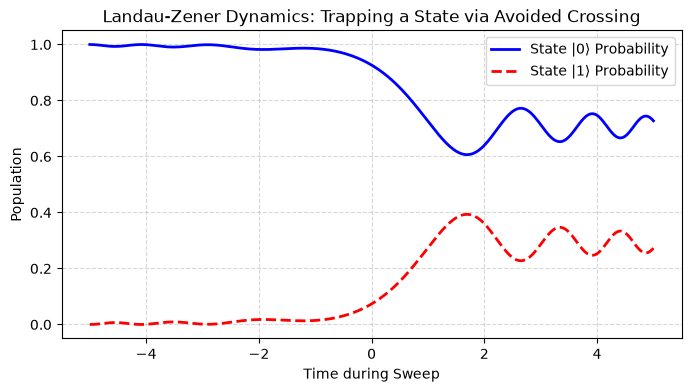

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# ---------------------------------------------------------
# 1. DEFINE A TIME-DEPENDENT HAMILTONIAN FUNCTION
# ---------------------------------------------------------
# QuTiP calls this function at every time step to get the current Hamiltonian matrix
def hamiltonian_t(t, args):
    v = args['v']            # The speed of our parameter sweep
    delta = args['delta']    # The minimum energy gap size (tunneling coupling)
    
    # Energy levels change linearly with time (v * t), while delta stays constant
    H_t = (v * t / 2.0) * qt.sigmaz() + (delta / 2.0) * qt.sigmax()
    return H_t

# ---------------------------------------------------------
# 2. SETUP THE SIMULATION PARAMETERS
# ---------------------------------------------------------
# Create an argument dictionary to pass to our function
args = {'v': 1.5, 'delta': 0.6}

# We sweep time from negative (-5) to positive (+5)
tlist = np.linspace(-5, 5, 300)

# Start 100% in the ground state |0>
psi0 = qt.basis(2, 0)

# ---------------------------------------------------------
# 3. RUN THE SIMULATION
# ---------------------------------------------------------
# We track the individual populations of state |0> and state |1> directly
p0_op = qt.basis(2, 0) * qt.basis(2, 0).dag()
p1_op = qt.basis(2, 1) * qt.basis(2, 1).dag()

# Pass the function name and the 'args' dictionary into the solver
result = qt.sesolve(hamiltonian_t, psi0, tlist, e_ops=[p0_op, p1_op], args=args)

# ---------------------------------------------------------
# 4. VISUALIZATION
# ---------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(tlist, result.expect[0], 'b-', lw=2, label=r'State $|0\rangle$ Probability')
plt.plot(tlist, result.expect[1], 'r--', lw=2, label=r'State $|1\rangle$ Probability')

plt.xlabel('Time during Sweep')
plt.ylabel('Population')
plt.title('Landau-Zener Dynamics: Trapping a State via Avoided Crossing')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

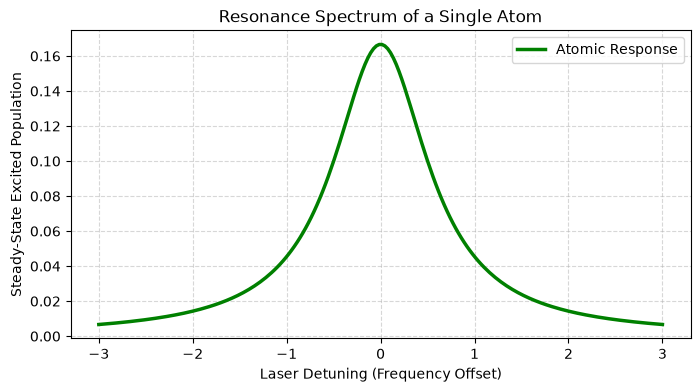

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# ---------------------------------------------------------
# 1. SETUP SYSTEM PARAMETERS & OPERATORS
# ---------------------------------------------------------
gamma = 1.0   # Atomic decay rate (spontaneous emission)
Omega = 0.5   # Laser drive strength (Rabi frequency)

# Two-level system operators
sm = qt.destroy(2)     # Lowering operator (\sigma_-)
sz = qt.sigmaz()       # Sigma-Z operator
sx = qt.sigmax()       # Sigma-X operator

# Tracker: excited state population operator (\sigma_+ \sigma_-)
excited_op = sm.dag() * sm 

# Collapse operator: Environment causing the atom to decay
c_ops = [np.sqrt(gamma) * sm]

# ---------------------------------------------------------
# 2. SWEEP LASER FREQUENCY (DETUNING)
# ---------------------------------------------------------
# Detuning measures how far the laser is from the atom's favorite frequency
detunings = np.linspace(-3.0, 3.0, 200)
excited_population = []

for delta in detunings:
    # Hamiltonian in the laser's rotating frame
    H = -0.5 * delta * sz + 0.5 * Omega * sx
    
    # CRITICAL: Find the steady state directly at t = infinity
    rho_ss = qt.steadystate(H, c_ops)
    
    # Measure how excited the atom is in this steady state
    pop = qt.expect(excited_op, rho_ss)
    excited_population.append(pop)

# ---------------------------------------------------------
# 3. VISUALIZATION
# ---------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(detunings, excited_population, 'g-', lw=2.5, label='Atomic Response')

plt.xlabel('Laser Detuning (Frequency Offset)')
plt.ylabel('Steady-State Excited Population')
plt.title('Resonance Spectrum of a Single Atom')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

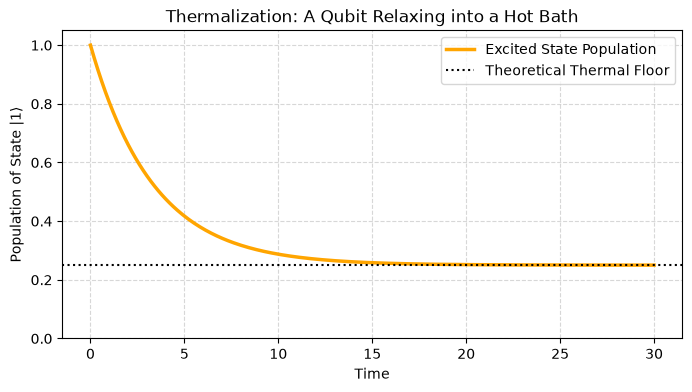

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# ---------------------------------------------------------
# 1. SETUP THE QUBIT AND THE HOT ENVIRONMENT
# ---------------------------------------------------------
H = 0.5 * qt.sigmaz()   # Qubit energy splitting
psi0 = qt.basis(2, 1)   # Start 100% in the excited state |1>

# Thermal bath parameters
gamma = 0.15           # Base system relaxation rate
n_th = 0.5             # Average thermal photon/phonon number (Temperature > 0)

# Collapse Operator 1: Environmental cooling (de-excitation)
c_down = np.sqrt(gamma * (1 + n_th)) * qt.destroy(2)

# Collapse Operator 2: Environmental heating (excitation from the hot bath)
c_up = np.sqrt(gamma * n_th) * qt.create(2)

# Combine both environmental forces
c_ops = [c_down, c_up]

# ---------------------------------------------------------
# 2. TIME EVOLUTION
# ---------------------------------------------------------
tlist = np.linspace(0, 30, 300)

# Track the excited state population operator (|1><1|)
excited_op = qt.basis(2, 1) * qt.basis(2, 1).dag()
result = qt.mesolve(H, psi0, tlist, c_ops=c_ops, e_ops=[excited_op])

# ---------------------------------------------------------
# 3. VISUALIZATION
# ---------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(tlist, result.expect[0], 'orange', lw=2.5, label='Excited State Population')

# Calculate the exact theoretical thermal floor
thermal_floor = n_th / (1 + 2 * n_th)
plt.axhline(y=thermal_floor, color='k', linestyle=':', label='Theoretical Thermal Floor')

plt.xlabel('Time')
# FIXED: Added the 'r' prefix to make it a raw string for LaTeX formatting
plt.ylabel(r'Population of State $|1\rangle$')
plt.title('Thermalization: A Qubit Relaxing into a Hot Bath')
plt.legend()
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()